### Import necessary libraries and modules

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor  
from sklearn.dummy import DummyRegressor


### Load data

In [91]:
df=pd.read_csv('housing.csv') 

### Understanding the data 


In [92]:
df.info()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


We have a complete dataset in the majority of variables. However, missingness occurs in the variable total_bedrooms (n=207)

### Split our data

In [93]:
train,test = train_test_split(df, test_size=0.2, random_state=42)   


### EDA on training dataset


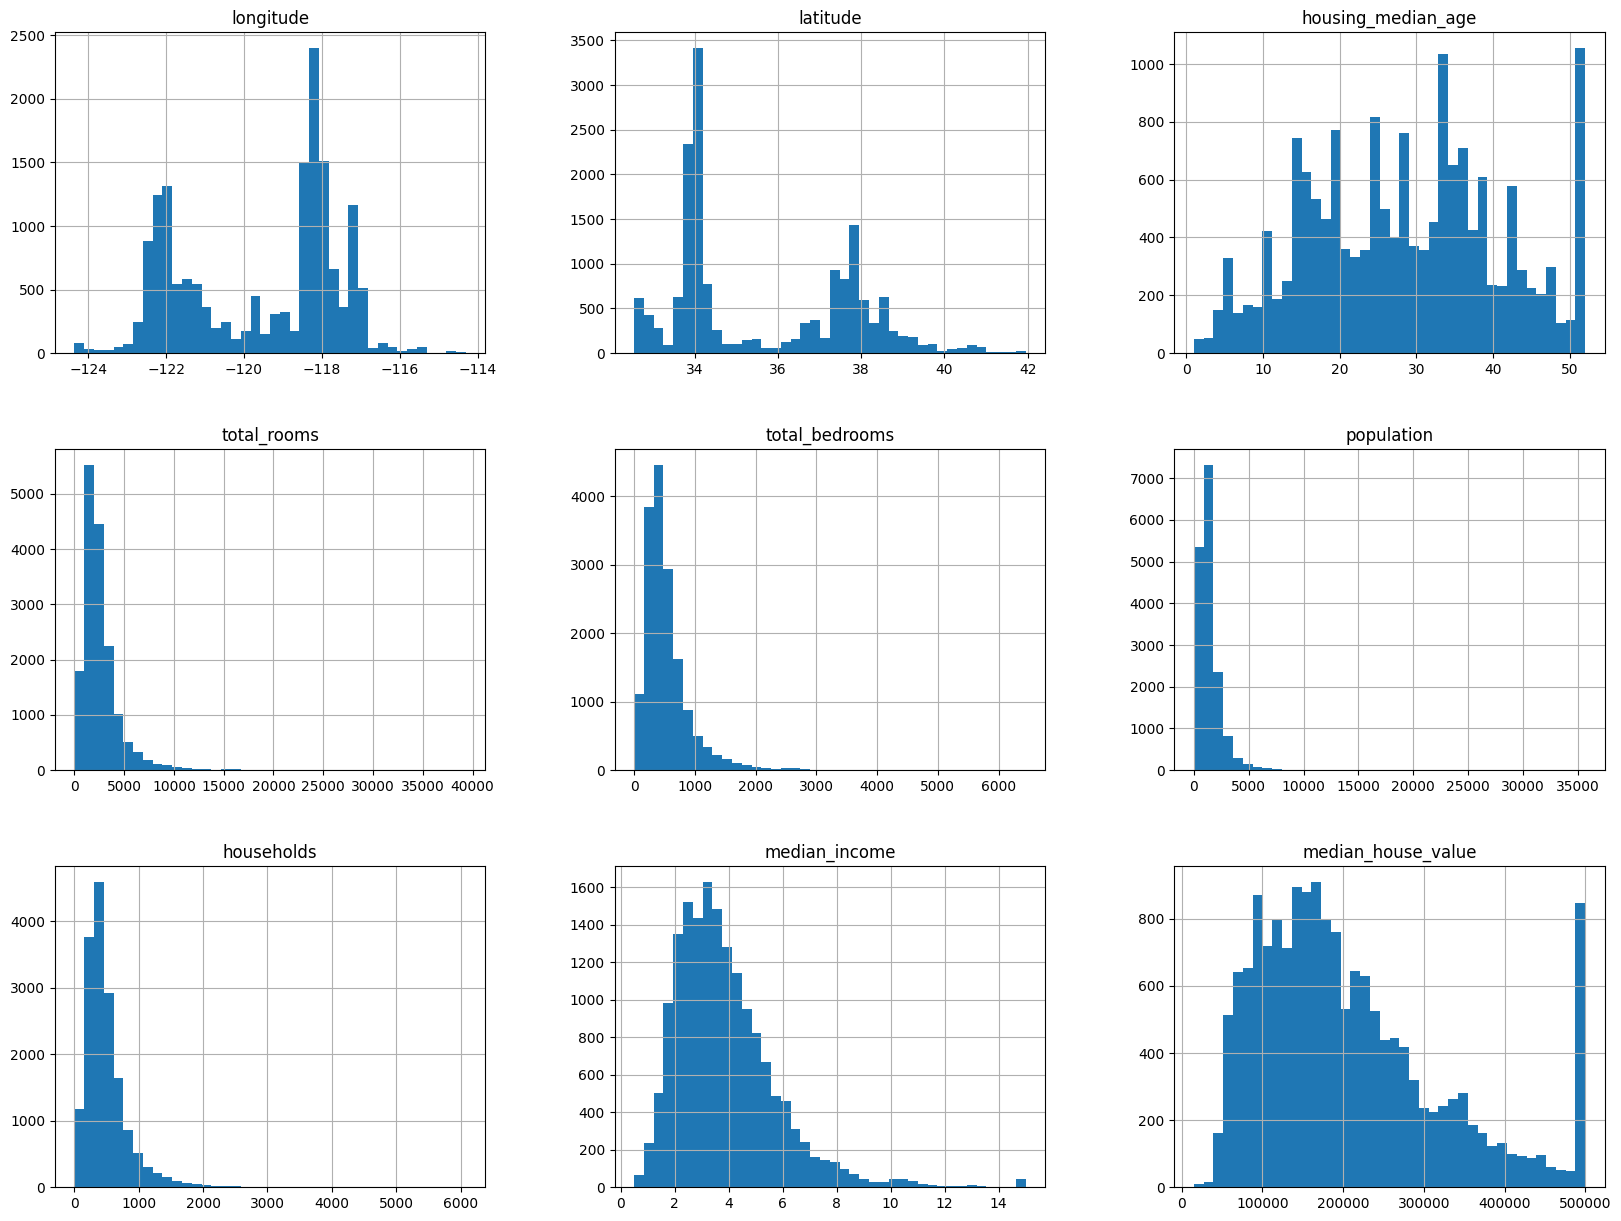

In [94]:
train.hist(bins=40, figsize=(20,15))
plt.show()

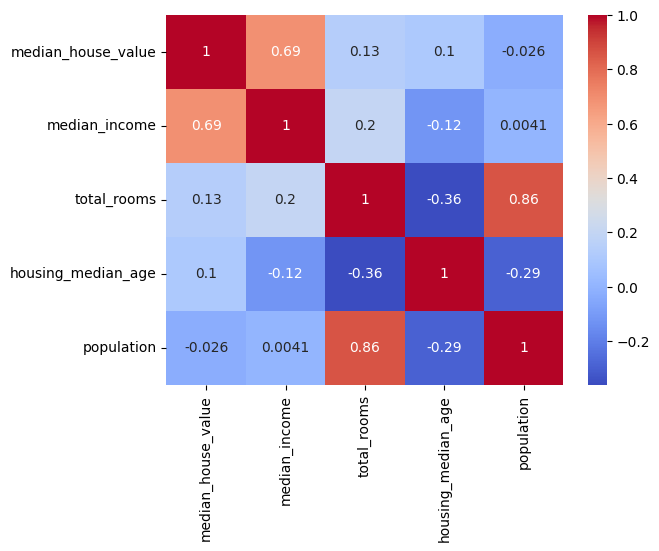

In [95]:
corr= train[['median_house_value','median_income','total_rooms','housing_median_age','population']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


In [96]:
train.columns
#convert to category 
train['ocean_proximity'] = train['ocean_proximity'].astype('category')
train['total_bedrooms'] = train['total_bedrooms'].astype('float')

train[['ocean_proximity']].value_counts(normalize=True)



ocean_proximity
<1H OCEAN          0.444586
INLAND             0.316558
NEAR OCEAN         0.126332
NEAR BAY           0.112282
ISLAND             0.000242
Name: proportion, dtype: float64

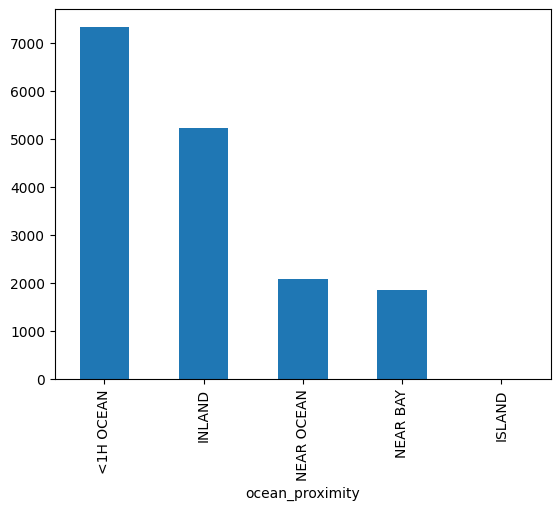

In [97]:
train['ocean_proximity'].value_counts().plot(kind='bar')
plt.show()

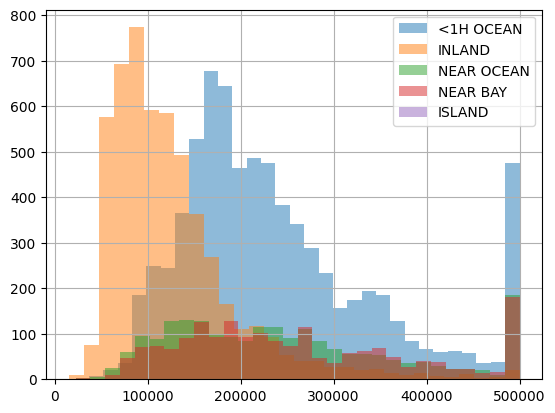

In [98]:
train.query('ocean_proximity == "<1H OCEAN"')['median_house_value'].hist(bins=30, alpha=0.5, label='<1H OCEAN')
train.query('ocean_proximity == "INLAND"')['median_house_value'].hist(bins=30, alpha=0.5, label='INLAND')
train.query('ocean_proximity == "NEAR OCEAN"')['median_house_value'].hist(bins=30, alpha=0.5, label='NEAR OCEAN')
train.query('ocean_proximity == "NEAR BAY"')['median_house_value'].hist(bins=30, alpha=0.5, label='NEAR BAY')
train.query('ocean_proximity == "ISLAND"')['median_house_value'].hist(bins=30, alpha=0.5, label='ISLAND')
plt.legend()    

In [99]:
x_train = train.drop('median_house_value', axis=1)
y_train = train['median_house_value']

### Evaluation

In [100]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = 'neg_root_mean_squared_error'

# Define features
numeric_features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
categorical_features = ['ocean_proximity']

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder())
        ]), categorical_features)
    ]
)

### Baseline 

In [101]:
Baseline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', LinearRegression())
    ])

baselinegrid = GridSearchCV(estimator=Baseline, param_grid={}, scoring=scoring, cv=cv, n_jobs=-1)
baselinegrid.fit(x_train, y_train)
print("Linear Regression - CV RMSE:", -baselinegrid.best_score_)

Lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('model', Lasso(alpha=0.1))
    ])
lasso_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0]
}
Lasso_grid = GridSearchCV(estimator=Lasso, param_grid=lasso_param_grid, scoring=scoring, cv=cv, n_jobs=-1)
Lasso_grid.fit(x_train, y_train)    
print("Lasso - CV RMSE:", -Lasso_grid.best_score_)

Ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('model', Ridge(alpha=1.0))
    ])
ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_grid = GridSearchCV(estimator=Ridge, param_grid=ridge_param_grid, scoring=scoring, cv=cv, n_jobs=-1)
ridge_grid.fit(x_train, y_train)
print("Ridge - CV RMSE:", -ridge_grid.best_score_)

ElasticNet = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('model', ElasticNet(alpha=0.1, l1_ratio=0.5))
    ])

elastic_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}
elastic_grid = GridSearchCV(estimator=ElasticNet, param_grid=elastic_param_grid, scoring=scoring, cv=cv, n_jobs=-1)
elastic_grid.fit(x_train, y_train)
print("ElasticNet - CV RMSE:", -elastic_grid.best_score_)

RandomForest = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
    ])

rf_grid = GridSearchCV(estimator=RandomForest, param_grid={}, scoring=scoring, cv=cv, n_jobs=-1
 )
rf_grid.fit(x_train, y_train)
print("Random Forest - CV RMSE:", -rf_grid.best_score_)




Linear Regression - CV RMSE: 68604.16295529755
Lasso - CV RMSE: 68599.84543755409
Ridge - CV RMSE: 68595.61739914856


c:\Users\chn03\Desktop\Machine learning\Housing price\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.866e+13, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(


ElasticNet - CV RMSE: 68594.92900363641
Random Forest - CV RMSE: 49445.28603543163
